In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path = "/content/drive/MyDrive/IT in Analytics/Python/Spring 2023/2022_dec_cleaned.csv"
dou = pd.read_csv(path, index_col=0, parse_dates=True)
dou.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13315 entries, 2022-11-30 10:26:37 to 2023-01-09 11:38:00
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employment_type       13315 non-null  object 
 1   in_ukraine            13315 non-null  bool   
 2   region                11538 non-null  object 
 3   salary                13288 non-null  float64
 4   gender                13315 non-null  object 
 5   age                   13315 non-null  float64
 6   education             13315 non-null  object 
 7   scientific_degree     13204 non-null  object 
 8   english_level         13315 non-null  object 
 9   position              13315 non-null  object 
 10  title                 13315 non-null  object 
 11  use_code              4874 non-null   object 
 12  programming_language  9060 non-null   object 
 13  specialization        9059 non-null   object 
 14  area                  13315 non-nul

In [ ]:
dou = dou.dropna(subset=['salary'])
dou.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13288 entries, 2022-11-30 10:26:37 to 2023-01-09 11:38:00
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employment_type       13288 non-null  object 
 1   in_ukraine            13288 non-null  bool   
 2   region                11538 non-null  object 
 3   salary                13288 non-null  float64
 4   gender                13288 non-null  object 
 5   age                   13288 non-null  float64
 6   education             13288 non-null  object 
 7   scientific_degree     13177 non-null  object 
 8   english_level         13288 non-null  object 
 9   position              13288 non-null  object 
 10  title                 13288 non-null  object 
 11  use_code              4874 non-null   object 
 12  programming_language  9035 non-null   object 
 13  specialization        9034 non-null   object 
 14  area                  13288 non-nul

In [ ]:
# ЗП по регіонам
# ЗП у галузях
# ЗП за рівнем англійської мови
# ЗП за досвідом

In [ ]:
plt.style.use('ggplot')

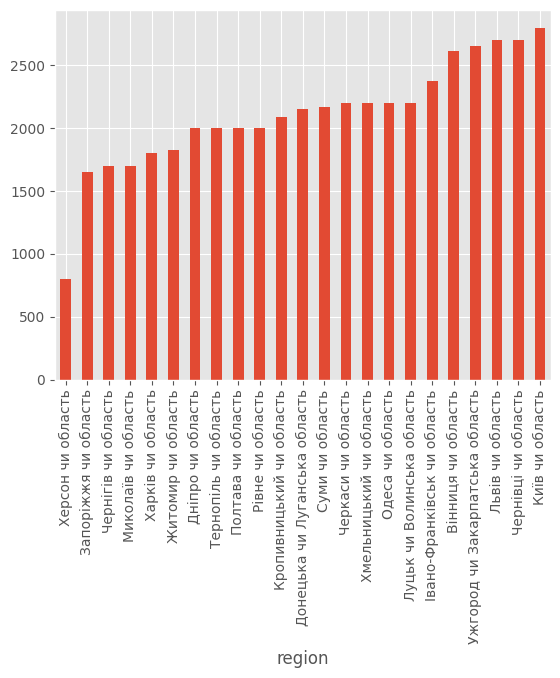

In [ ]:
# Pandas-style
dou.groupby('region')['salary'].median().sort_values().plot(kind='bar')
plt.show()

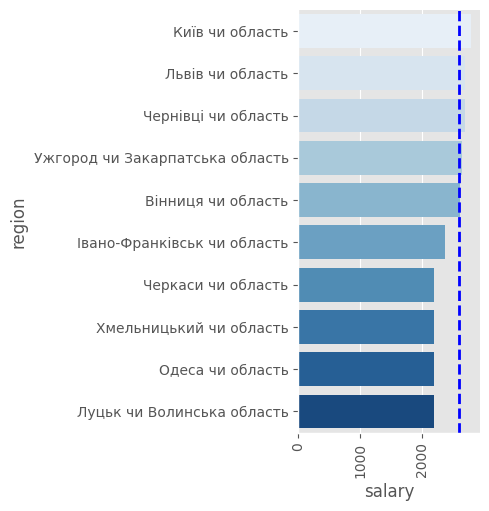

In [ ]:
top_10_regions = dou.groupby('region')['salary'].median().sort_values(ascending=False).head(10).index
custom_regions = dou[dou['region'].isin(top_10_regions)]
sns.catplot(data=custom_regions, y="region", x="salary",
            estimator=np.median, kind='bar', errorbar=('ci', False),
            palette="Blues", order=top_10_regions)
plt.axvline(x=dou['salary'].median(), linewidth=2, linestyle='--', color='blue')
plt.xticks(rotation=90)
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


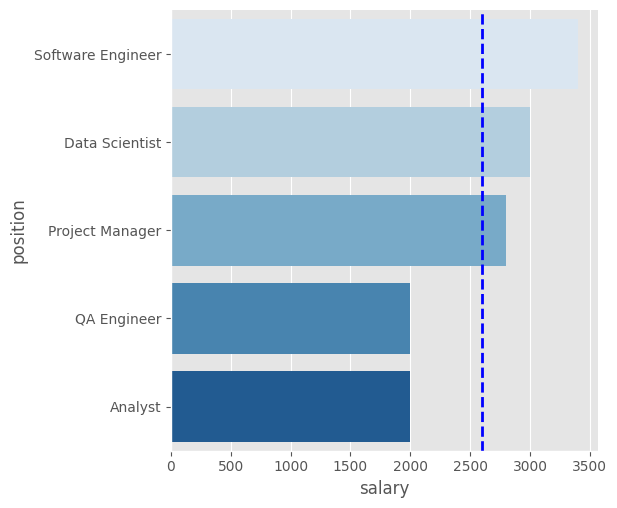

In [ ]:
# dou['position'].value_counts()
my_positions = ['Software Engineer (Junior, Middle, Senior, Team/Tech Lead, Architect)',
                'Data Science, Machine Learning, Big Data',
                'Project/Product/Program Manager, Product Owner, Scrum Master, Delivery Manager',
                'QA Engineer (Junior, Middle, Senior, Team/Tech Lead, Manager)',
                'Analyst (Business, Data, System)'
                ]
dou_my_positions = dou[dou['position'].isin(my_positions)]

sns.catplot(data=dou_my_positions, y="position", x="salary",
            estimator=np.median, kind='bar', errorbar=('ci', False),
            palette="Blues", order=my_positions)
plt.axvline(x=dou['salary'].median(), linewidth=2, linestyle='--', color='blue')
plt.yticks(ticks=np.arange(5),
           labels=['Software Engineer', 'Data Scientist', 'Project Manager', 'QA Engineer', 'Analyst']
           )
plt.show()

In [ ]:
sorted(dou['work_experience'].unique())

[0.0,
 0.25,
 0.5,
 1.0,
 1.5,
 2.0,
 3.0,
 4.0,
 5.0,
 6.0,
 7.0,
 8.0,
 9.0,
 10.0,
 11.0,
 12.0,
 13.0,
 14.0,
 15.0]

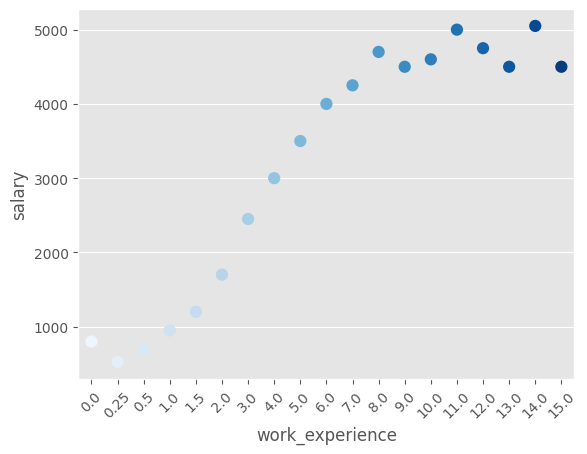

In [ ]:
sns.pointplot(x="work_experience",
              y="salary",
              data=dou,
              estimator=np.median,
              errorbar=('ci', False),
              order=sorted(dou['work_experience'].unique()),
              palette="Blues"
              )
# plt.xticks(ticks=sorted(dou['work_experience'].unique()),
#            labels=['', '', '', '1 рік', '', '', '3 роки', '', '5 років', '', '7 років', '', '9 років',
#                    '', '11 років', '', '13 років', '', '15+ років'],
#            rotation=90)
plt.xticks(rotation=45)
plt.show()

In [ ]:
groupedvalues = dou.groupby('english_level')['salary'].median().sort_values(ascending=False).reset_index()
groupedvalues

,english_level,salary
0,Advanced,3500.0
1,Upper-Intermediate,3300.0
2,Intermediate,2125.0
3,Pre-Intermediate,1404.0
4,Elementary,1155.0


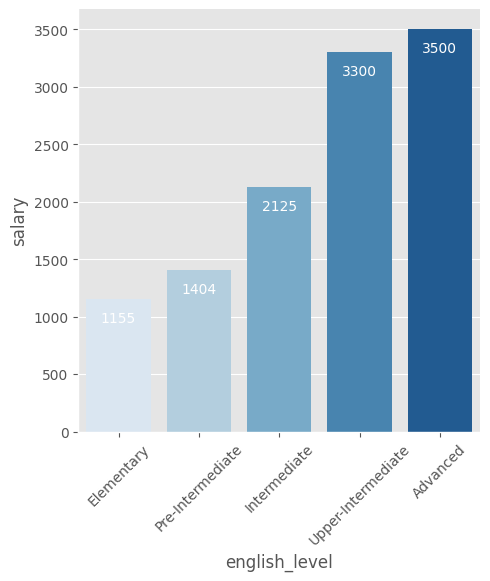

In [ ]:
sns.catplot(x="english_level",
            y="salary",
            data=dou,
            estimator=np.median,
            errorbar=('ci', False),
            order=['Elementary', 'Pre-Intermediate', 'Intermediate', 'Upper-Intermediate', 'Advanced'],
            palette="Blues",
            kind='bar'
            )
plt.xticks(rotation=45)

groupedvalues = dou.groupby('english_level')['salary'].median().sort_values().reset_index()

for index, row in groupedvalues.iterrows():
    plt.text(row.name, row['salary']-200, np.int32(row['salary']), color='white', ha='center')

plt.show()

In [ ]:
type(dou.groupby('english_level')['salary'].median().sort_values())

pandas.core.series.Series

In [ ]:
dou.groupby('english_level')['salary'].median().sort_values().reset_index()

,english_level,salary
0,Elementary,1155.0
1,Pre-Intermediate,1404.0
2,Intermediate,2125.0
3,Upper-Intermediate,3300.0
4,Advanced,3500.0


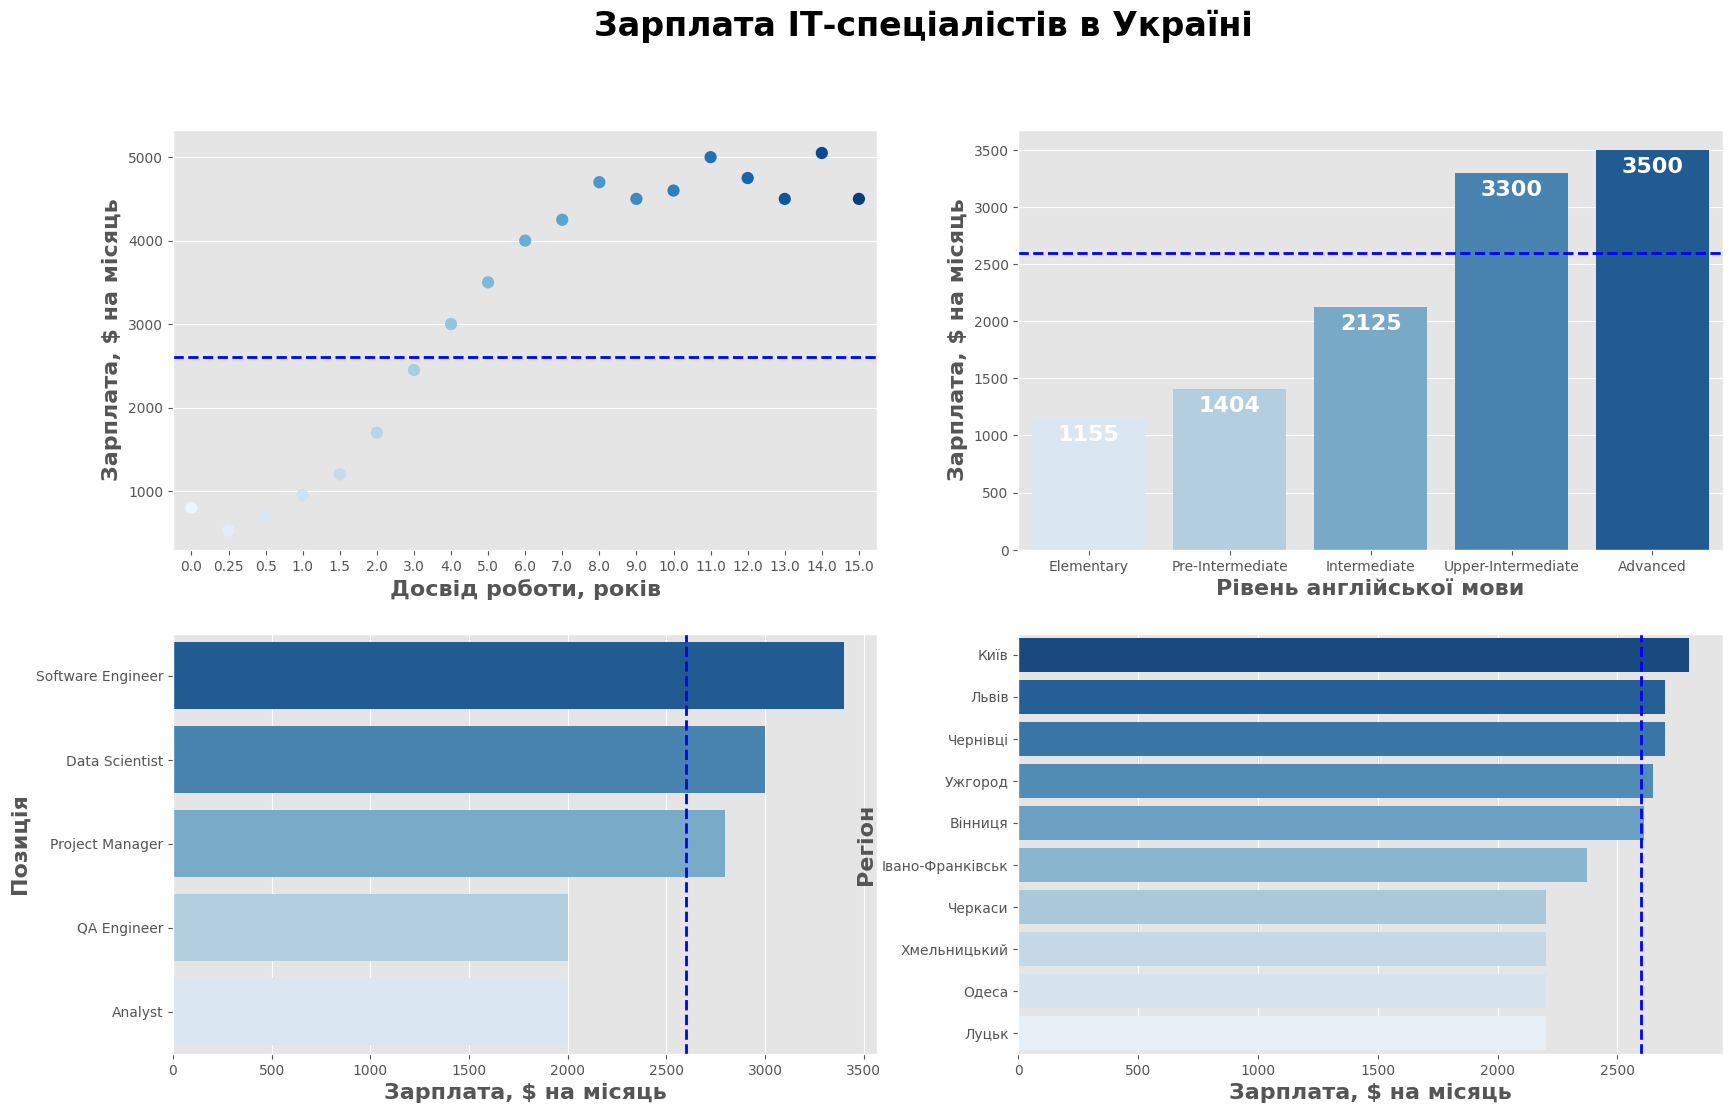

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(20, 12))

# Salary - work experience
sns.pointplot(x="work_experience",
              y="salary",
              data=dou,
              estimator=np.median,
              errorbar=('ci', False),
              order=sorted(dou['work_experience'].unique()),
              palette="Blues",
              ax=ax[0, 0]
             )

ax[0, 0].axhline(y=dou['salary'].median(), linewidth=2, linestyle='--', color='blue')

ax[0, 0].set_xlabel('Досвід роботи, років', fontsize=16, weight='bold')
ax[0, 0].set_ylabel('Зарплата, $ на місяць', fontsize=16, weight='bold')

# Salary - English level
sns.barplot(x="english_level",
            y="salary",
            data=dou,
            estimator=np.median,
            errorbar=('ci', False),
            order=['Elementary', 'Pre-Intermediate', 'Intermediate', 'Upper-Intermediate', 'Advanced'],
            palette="Blues",
            ax=ax[0, 1]
            )

ax[0, 1].axhline(y=dou['salary'].median(), linewidth=2, linestyle='--', color='blue')

groupedvalues = dou.groupby('english_level')['salary'].median().sort_values().reset_index()

for index, row in groupedvalues.iterrows():
    ax[0, 1].text(row.name, row['salary']-200, np.int32(row['salary']), color='white', ha='center',
                  fontsize=16, weight='bold')

ax[0, 1].set_xlabel('Рівень англійської мови', fontsize=16, weight='bold')
ax[0, 1].set_ylabel('Зарплата, $ на місяць', fontsize=16, weight='bold')

# Salary - area
my_positions = ['Software Engineer (Junior, Middle, Senior, Team/Tech Lead, Architect)',
                'Data Science, Machine Learning, Big Data',
                'Project/Product/Program Manager, Product Owner, Scrum Master, Delivery Manager',
                'QA Engineer (Junior, Middle, Senior, Team/Tech Lead, Manager)',
                'Analyst (Business, Data, System)'
                ]
dou_my_positions = dou[dou['position'].isin(my_positions)]

sns.barplot(x="salary",
            y="position",
            data=dou_my_positions,
            estimator=np.median,
            errorbar=('ci', False),
            palette="Blues_r",
            order=my_positions,
            ax=ax[1, 0]
            )
ax[1, 0].axvline(x=dou['salary'].median(), linewidth=2, linestyle='--', color='blue')
ax[1, 0].set_yticks(ticks=np.arange(5),
                    labels=['Software Engineer', 'Data Scientist', 'Project Manager', 'QA Engineer',  'Analyst']
                    )
ax[1, 0].set_xlabel('Зарплата, $ на місяць', fontsize=16, weight='bold')
ax[1, 0].set_ylabel('Позиція', fontsize=16, weight='bold')

# Salary - region

top_10_regions = dou.groupby('region')['salary'].median().sort_values(ascending=False).head(10).index
top_10_regions_shortnames = [x.split()[0] for x in top_10_regions]
custom_regions = dou[dou['region'].isin(top_10_regions)]
sns.barplot(x="salary",
            y="region",
            data=custom_regions,
            estimator=np.median,
            errorbar=('ci', False),
            palette="Blues_r",
            order=top_10_regions,
            ax=ax[1, 1]
            )
ax[1, 1].axvline(x=dou['salary'].median(), linewidth=2, linestyle='--', color='blue')
ax[1, 1].set_yticks(ticks=np.arange(10),
                    labels=top_10_regions_shortnames
                    )
ax[1, 1].set_xlabel('Зарплата, $ на місяць', fontsize=16, weight='bold')
ax[1, 1].set_ylabel('Регіон', fontsize=16, weight='bold')

# Назва дашборду
fig.suptitle('Зарплата ІТ-спеціалістів в Україні', fontsize=24, weight='bold')

plt.savefig('/content/drive/MyDrive/IT in Analytics/Python/Spring 2023/dashboard.png')

plt.show()